In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [2]:

#from github
username = "datagus"
repository = "ASDA2025"
directory = "datasets/homework_week11/6.3.3_spotify_5000_songs.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
spotify_df = pd.read_csv(github_url)

In [3]:
spotify_df.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [4]:
spotify_df.columns = spotify_df.columns.str.strip()

In [5]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5235 entries, 0 to 5234
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              5235 non-null   object 
 1   artist            5235 non-null   object 
 2   danceability      5235 non-null   float64
 3   energy            5235 non-null   float64
 4   key               5235 non-null   int64  
 5   loudness          5235 non-null   float64
 6   mode              5235 non-null   int64  
 7   speechiness       5235 non-null   float64
 8   acousticness      5235 non-null   float64
 9   instrumentalness  5235 non-null   float64
 10  liveness          5235 non-null   float64
 11  valence           5235 non-null   float64
 12  tempo             5235 non-null   float64
 13  duration_ms       5235 non-null   int64  
 14  time_signature    5235 non-null   int64  
 15  id                5235 non-null   object 
 16  html              5235 non-null   object 


In [6]:
features = [
    "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence",
    "tempo" 
]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(spotify_df.select_dtypes(include=[np.number]))

In [22]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

spotify_df = spotify_df.loc[spotify_df.index]
spotify_df["cluster"] = clusters

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

spotify_df["PC1"] = X_pca[:, 0]
spotify_df["PC2"] = X_pca[:, 1]

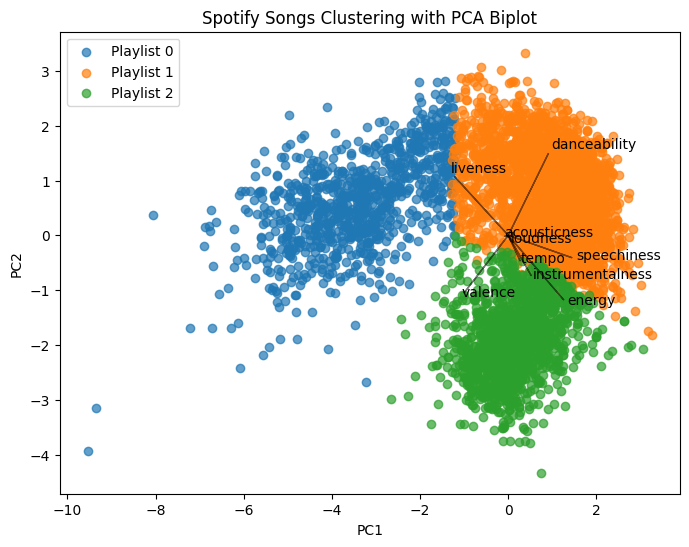

In [24]:
plt.figure(figsize=(8, 6))

for c in range(k):
    subset = spotify_df[spotify_df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Playlist {c}", alpha=0.7)

# PCA loadings (biplot arrows)
loadings = pca.components_.T
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, color="black", alpha=0.5)
    plt.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Spotify Songs Clustering with PCA Biplot")
plt.show()


In [25]:
spotify_df.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html,cluster,PC1,PC2
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...,1,-0.538288,0.610676
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...,1,0.244578,1.845867
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...,1,1.630503,1.286562
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,0,-1.550708,2.486887
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,0,-2.060739,2.287592


In [26]:
spotify_df[spotify_df["cluster"] == 0].head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html,cluster,PC1,PC2
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,0,-1.550708,2.486887
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,0,-2.060739,2.287592
5,Desafinado ...,Stan Getz,0.466,0.1460,3,-17.500,1,0.0649,0.931,0.154000,0.107,0.423,142.885,249387,4,5pstSsK0G4q86gdyy1Spqh,https://open.spotify.com/track/5pstSsK0G4q86gd...,0,-2.038083,1.540465
6,Madalena ...,Maria Gasolina,0.675,0.2070,11,-13.820,0,0.0545,0.963,0.414000,0.112,0.684,93.531,145187,4,33u3dO0JWjerYpFN61J3ug,https://open.spotify.com/track/33u3dO0JWjerYpF...,0,-1.388058,2.366963
10,The Girl From Ipanema ...,Stan Getz,0.641,0.1400,8,-16.790,1,0.0390,0.867,0.001660,0.105,0.388,129.318,317987,4,4xGFcQEIjtmbPD6Jsxq14M,https://open.spotify.com/track/4xGFcQEIjtmbPD6...,0,-1.778097,1.984491


In [27]:
spotify_df[spotify_df["cluster"] == 1].head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,id,html,cluster,PC1,PC2
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.259,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...,1,-0.538288,0.610676
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.399,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...,1,0.244578,1.845867
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.730,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...,1,1.630503,1.286562
7,O Meu Amor É Glòria ...,Sílvia Pérez Cruz,0.504,0.733,7,-10.720,1,0.3890,0.696,0.000056,0.673,0.886,96.565,309760,4,0ylJQpV3K4XnhWhLDMFmH7,https://open.spotify.com/track/0ylJQpV3K4XnhWh...,1,1.139571,-0.254600
8,Brigas Nunca Mais ...,Paula Morelenbaum,0.694,0.546,10,-11.452,1,0.0400,0.398,0.076000,0.153,0.641,170.032,204027,4,1wL2dk42Cxu4zCJs4SvFsZ,https://open.spotify.com/track/1wL2dk42Cxu4zCJ...,1,0.450499,1.158417


In [28]:
cluster_means = spotify_df.groupby("cluster")[features].mean()
cluster_means

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.357738,0.153557,-20.043543,0.045201,0.906630,0.588775,0.145811,0.210710,105.890632
1,0.659503,0.689881,-6.895856,0.081110,0.229742,0.036467,0.184579,0.620252,120.635521
2,0.297770,0.898922,-7.513054,0.111754,0.019436,0.499972,0.212267,0.228912,122.994873
